In [1]:
# This information helps with debugging and getting support :)
import sys, platform
import pandas as pd
import bifacial_radiance as br
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("bifacial_radiance version ", br.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
bifacial_radiance version  0.5.1.dev12+ga93ff8171.d20251201


In [2]:
import os
from pathlib import Path

testfolder = 'TEMP'
if not os.path.exists(testfolder):
    os.makedirs(testfolder)

print ("Your simulation will be stored in %s" % testfolder)


Your simulation will be stored in TEMP


In [3]:
import bifacial_radiance
import numpy as np

rad_obj = bifacial_radiance.RadianceObj('Si', str(testfolder)) 


path = TEMP


<a id='step1'></a>

## 1. Making Collectors for each number panel and xgap case

In [4]:
rad_obj.setGround(0.2)  # This prints available materials.

Loading albedo, 1 value(s), 0.200 avg
1 nonzero albedo values.


In [5]:
epwfile = rad_obj.getEPW(lat = 42.98, lon = -81.24)

Getting weather file: CAN_ON_London.716230_CWEC.epw
 ... OK!


In [6]:
startdate = '04_01'     
enddate = '10_31'
metdata = rad_obj.readWeatherFile(epwfile, coerce_year=2025, starttime=startdate, endtime=enddate)


8760 line in WeatherFile. Assuming this is a standard hourly WeatherFile for the year for purposes of saving Gencumulativesky temporary weather files in EPW folder.
Coercing year to 2025
Filtering dates
Saving file EPWs\metdata_temp.csv, # points: 8760
Calculating Sun position for Metdata that is right-labeled  with a delta of -30 mins. i.e. 12 is 11:30 sunpos


In [7]:
metdata

<class 'bifacial_radiance.main.MetObj'>.metadata:
{'latitude': 43.03, 'longitude': -81.15, 'elevation': 278.0, 'timezone': -5.0, 'city': 'London', 'label': 'right'}
<class 'bifacial_radiance.main.MetObj'>.tmydata:
 <class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2898 entries, 2025-04-01 07:00:00-05:00 to 2025-10-31 17:00:00-05:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ghi         2898 non-null   int64  
 1   dhi         2898 non-null   int64  
 2   dni         2898 non-null   int64  
 3   albedo      2898 non-null   float64
 4   dewpoint    2898 non-null   float64
 5   pressure    2898 non-null   int64  
 6   temp_air    2898 non-null   float64
 7   wind_speed  2898 non-null   float64
dtypes: float64(4), int64(4)

In [8]:
#rad_obj.genCumSky() # entire year.
metdata.datetime[1035] # Selected for having GHI = 982 , clear sky day. # ('2025-06-13 13:00:00-0500', tz='UTC-05:00')
timeindex = metdata.datetime.index(pd.to_datetime('2025-06-13 13:00:00 -5'))
rad_obj.gendaylit(timeindex)  # Noon, June 17th (timepoint # 4020)

'skies\\sky2_43.03_-81.15_2025-06-13_1300.rad'

In [9]:
# Si 08
numcellsx = 6
numcellsy = 22
xcell = 0.166 # m
ycell = 0.083 # m
xcellgap = 0.002 # m
ycellgap = 0.002

x =  1.039 # m
y = 2.095  # m
xgap = 0.005 # m
ygap = 0
numpanels = 1

Si_08 = rad_obj.makeModule(name='Si_08',  x=x, y=y, xgap=xgap, ygap=ygap, 
                           numpanels=numpanels) 
Si_08.addCellModule(numcellsx=numcellsx, numcellsy=numcellsy,
                       xcell=xcell, ycell=ycell, xcellgap=xcellgap, ycellgap=ycellgap)

print(f'New module created. x={Si_08.x}m,  y={Si_08.y}m')
print(f'Cell-module parameters: {Si_08.cellModule}')


Module Name: Si_08
Module Si_08 updated in module.json
Pre-existing .rad file objects\Si_08.rad will be overwritten

Module was shifted by 0.083 in X to avoid sensors on air
This is a Cell-Level detailed module with Packaging Factor of 0.97 
Module Si_08 updated in module.json
Pre-existing .rad file objects\Si_08.rad will be overwritten

New module created. x=1.006m,  y=1.868m
Cell-module parameters: {'numcellsx': 6, 'numcellsy': 22, 'xcell': 0.166, 'ycell': 0.083, 'xcellgap': 0.002, 'ycellgap': 0.002, 'centerJB': None}


In [10]:
numcellsx = 2
numcellsy = 22
xcell = 0.166 # m
ycell = 0.083 # m
xcellgap = 0.662 # m
ycellgap = 0.002

x =  1.039 # m
y = 2.095  # m
xgap = 0.048 # m
ygap = 0
numpanels = 1

Si_69 = rad_obj.makeModule(name='Si_69',  x=x, y=y, xgap=xgap, ygap=ygap, 
                           numpanels=numpanels) 
Si_69.addCellModule(numcellsx=numcellsx, numcellsy=numcellsy,
                       xcell=xcell, ycell=ycell, xcellgap=xcellgap, ycellgap=ycellgap)

print(f'New module created. x={Si_69.x}m,  y={Si_69.y}m')
print(f'Cell-module parameters: {Si_69.cellModule}')


Module Name: Si_69
Module Si_69 updated in module.json
Pre-existing .rad file objects\Si_69.rad will be overwritten

Module was shifted by 0.083 in X to avoid sensors on air
This is a Cell-Level detailed module with Packaging Factor of 0.33 
Module Si_69 updated in module.json
Pre-existing .rad file objects\Si_69.rad will be overwritten

New module created. x=0.994m,  y=1.868m
Cell-module parameters: {'numcellsx': 2, 'numcellsy': 22, 'xcell': 0.166, 'ycell': 0.083, 'xcellgap': 0.662, 'ycellgap': 0.002, 'centerJB': None}


In [11]:
numcellsx = 4
numcellsy = 22
xcell = 0.166 # m
ycell = 0.083 # m
xcellgap = 0.11 # m
ycellgap = 0.002

x =  1.039 # m
y = 2.095  # m
xgap = 0.048 # m
ygap = 0
numpanels = 1

Si_44 = rad_obj.makeModule(name='Si_44',  x=x, y=y, xgap=xgap, ygap=ygap, 
                           numpanels=numpanels) 
Si_44.addCellModule(numcellsx=numcellsx, numcellsy=numcellsy,
                       xcell=xcell, ycell=ycell, xcellgap=xcellgap, ycellgap=ycellgap)

print(f'New module created. x={Si_44.x}m,  y={Si_44.y}m')
print(f'Cell-module parameters: {Si_44.cellModule}')


Module Name: Si_44
Module Si_44 updated in module.json
Pre-existing .rad file objects\Si_44.rad will be overwritten

Module was shifted by 0.083 in X to avoid sensors on air
This is a Cell-Level detailed module with Packaging Factor of 0.65 
Module Si_44 updated in module.json
Pre-existing .rad file objects\Si_44.rad will be overwritten

New module created. x=0.994m,  y=1.868m
Cell-module parameters: {'numcellsx': 4, 'numcellsy': 22, 'xcell': 0.166, 'ycell': 0.083, 'xcellgap': 0.11, 'ycellgap': 0.002, 'centerJB': None}


In [12]:
sceneDict1 = {'tilt':34,'pitch':5.69,'clearance_height':0.7,'azimuth':180, 'nMods': 3, 'nRows': 1, 'originx': -3.827, 'originy': 0, 'appendRadfile':True} 
sceneDict2 = {'tilt':34,'pitch':5.69,'clearance_height':0.7,'azimuth':180, 'nMods': 3, 'nRows': 1, 'originx': 0, 'originy': 0, 'appendRadfile':True} 
sceneDict3 = {'tilt':34,'pitch':5.69,'clearance_height':0.7,'azimuth':180, 'nMods': 3, 'nRows': 1, 'originx': 3.827, 'originy': 0, 'appendRadfile':True}


sceneObj1 = rad_obj.makeScene(Si_08, sceneDict1)  
sceneObj2 = rad_obj.makeScene(Si_69, sceneDict2, append=True)  
sceneObj3 = rad_obj.makeScene(Si_44, sceneDict3, append=True)  


Additional scene Scene1 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene2 created! See list of names with RadianceObj.scenes and sceneNames


In [13]:
octfile = rad_obj.makeOct(rad_obj.getfilelist()) 

Created Si.oct


In [14]:
rad_obj.getfilelist()

['materials\\ground.rad',
 'skies\\sky2_43.03_-81.15_2025-06-13_1300.rad',
 'objects\\Si_08_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin-3.827,0.rad',
 'objects\\Si_69_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin0,0.rad',
 'objects\\Si_44_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin3.827,0.rad']

In [15]:
#!objview materials\ground.rad objects\\Si_44_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin3.827,0.rad


In [16]:
#!rvu -vf views\front.vp -e .02 -pe 0.3 -vp 0 -10 11 -vd 0 0.7 -0.7 Si.oct

In [17]:
analysis = bifacial_radiance.AnalysisObj()

In [18]:
groundscan = analysis.groundAnalysis(sceneObj2, modWanted=2, rowWanted=1, sensorsground=2, sensorsgroundx=2)

In [19]:
groundscan

{'xstart': np.float16(0.0),
 'ystart': np.float16(0.0),
 'zstart': np.float16(0.05),
 'xinc': np.float16(0.0),
 'yinc': np.float16(-5.69),
 'zinc': np.float16(0.0),
 'sx_xinc': np.float64(0.3473333333333333),
 'sx_yinc': np.float64(4.2536065490384735e-17),
 'sx_zinc': 0.0,
 'Nx': 2,
 'Ny': 2,
 'Nz': 1,
 'orient': '0 0 -1'}

In [20]:
# Faster
#groundscan['xstart'] = -6.4
#groundscan['ystart'] = -1.2
#groundscan['Nx'] = 12
#groundscan['Ny'] = 26
#groundscan['yinc'] = 0.5
#groundscan['sx_xinc'] = 0.5
#groundscan['sx_yinc'] = 0.0

In [21]:
# SUPER RESOLUTION 5 cm
groundscan['xstart'] = -6.4
groundscan['ystart'] = -1.2
groundscan['Nx'] = 256
groundscan['Ny'] = 138
groundscan['yinc'] = 0.05
groundscan['sx_xinc'] = 0.05
groundscan['sx_yinc'] = 0.0

In [22]:
analysis.analysis(octfile, 'test_noon_5cm', groundscan)  # compare the back vs front irradiance

Linescan in process: test_noon_5cm_Row1_Module2_Front
Saved: results\irr_test_noon_5cm_Row1_Module2.csv


{'Wm2': array([978.976 , 978.9983, 979.0205, ..., 980.0357, 980.0419, 980.048 ]),
 'x': array([-6.4 , -6.4 , -6.4 , ...,  6.35,  6.35,  6.35]),
 'y': array([-1.2 , -1.15, -1.1 , ...,  5.55,  5.6 ,  5.65]),
 'z': array([0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05]),
 'r': array([978.976 , 978.9983, 979.0205, ..., 980.0357, 980.0419, 980.048 ]),
 'g': array([978.976 , 978.9983, 979.0205, ..., 980.0357, 980.0419, 980.048 ]),
 'b': array([978.976 , 978.9983, 979.0205, ..., 980.0357, 980.0419, 980.048 ]),
 'mattype': array(['groundplane', 'groundplane', 'groundplane', ..., 'groundplane',
        'groundplane', 'groundplane'], dtype='<U32'),
 'title': 'test_noon_5cm_Row1_Module2_Front'}

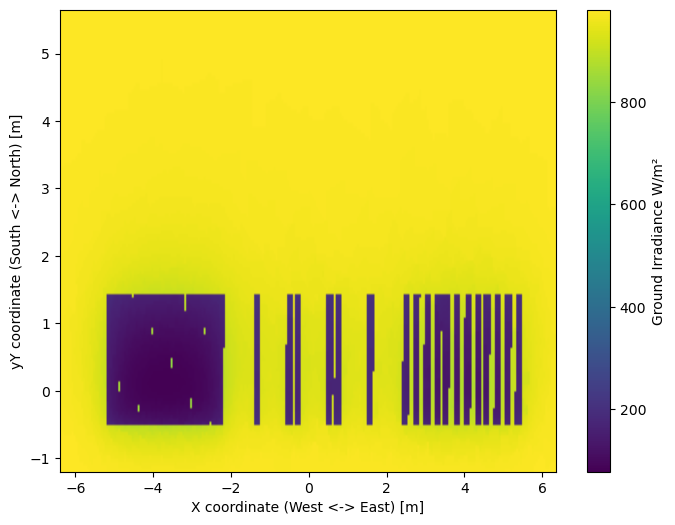

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr_test_noon_5cm_Row1_Module2.csv')   # columns: x, y, z, mattype, Wm2Front

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
# IMPORTANT: df is sorted so reshape works correctly
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto')

plt.colorbar(label='Ground Irradiance W/m²')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('yY coordinate (South <-> North) [m]')
#plt.title('Ground Irradiance')
plt.show()

In [24]:
## Seasonal
rad_obj.genCumSky() # entire year.
octfile = rad_obj.makeOct(rad_obj.getfilelist()) 
rad_obj.getfilelist()

Loaded  EPWs\metdata_temp.csv
message: Error!  Solar altitude is -6 < -6 degrees and Idh = 34 > 10 W/m^2 on day 91 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -8 < -6 degrees and Idh = 11 > 10 W/m^2 on day 132 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 14 > 10 W/m^2 on day 136 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 11 > 10 W/m^2 on day 137 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 12 > 10 W/m^2 on day 138 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 14 > 10 W/m^2 on day 140 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 21 > 10 W/m^2 on day 215 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 18 > 10 W/m^2 on day 215 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 15 > 1

['materials\\ground.rad',
 'skies\\cumulative.rad',
 'objects\\Si_08_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin-3.827,0.rad',
 'objects\\Si_69_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin0,0.rad',
 'objects\\Si_44_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin3.827,0.rad']

In [25]:
analysis.analysis(octfile, 'test_Season_5cm', groundscan)  # compare the back vs front irradiance

Linescan in process: test_Season_5cm_Row1_Module2_Front
Saved: results\irr_test_Season_5cm_Row1_Module2.csv


{'Wm2': array([1052108., 1051360., 1050612., ..., 1074634., 1074671., 1074709.]),
 'x': array([-6.4 , -6.4 , -6.4 , ...,  6.35,  6.35,  6.35]),
 'y': array([-1.2 , -1.15, -1.1 , ...,  5.55,  5.6 ,  5.65]),
 'z': array([0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05]),
 'r': array([1052108., 1051360., 1050612., ..., 1074634., 1074671., 1074709.]),
 'g': array([1052108., 1051360., 1050612., ..., 1074634., 1074671., 1074709.]),
 'b': array([1052108., 1051360., 1050612., ..., 1074634., 1074671., 1074709.]),
 'mattype': array(['groundplane', 'groundplane', 'groundplane', ..., 'groundplane',
        'groundplane', 'groundplane'], dtype='<U32'),
 'title': 'test_Season_5cm_Row1_Module2_Front'}

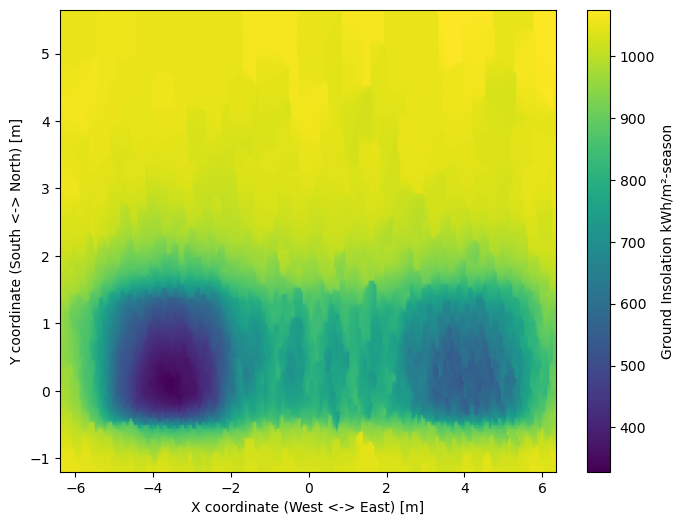

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr_test_Season_5cm_Row1_Module2.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Convert Wh/m² → kWh/m² ---
Z = Z / 1000.0     # <<< THIS LINE FIXES THE 1e6 SCALE ISSUE

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto')

plt.colorbar(label='Ground Insolation kWh/m²-season')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('Y coordinate (South <-> North) [m]')
plt.show()


In [27]:
print("Max Wh/m²-season:", df['Wm2Front'].max())
print("Max kWh/m²-season:", df['Wm2Front'].max() / 1000)


Max Wh/m²-season: 1074811.0
Max kWh/m²-season: 1074.811


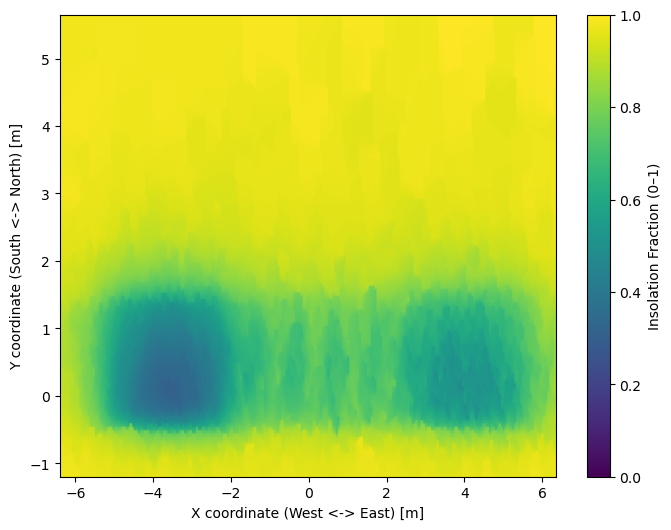

Max value in dataset: 1074811.0


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr_test_Season_5cm_Row1_Module2.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Normalize by max to get Insolation Fraction ---
Zmax = Z.max()
Z = Z / Zmax       # values now between 0 and 1

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto',
           vmin=0, vmax=1)   # enforce 0–1 scale

plt.colorbar(label='Insolation Fraction (0–1)')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('Y coordinate (South <-> North) [m]')
plt.show()

print("Max value in dataset:", Zmax)


In [29]:
target_x = -4
target_y = 0.2

# compute distance to each row
df['dist'] = np.sqrt((df['x'] - target_x)**2 + (df['y'] - target_y)**2)

# pick closest row
closest = df.loc[df['dist'].idxmin()]

print("Closest grid point:", closest[['x', 'y']].to_dict())
print("Wm2Front value:", closest['Wm2Front'])
print("Normalized value:", closest['Wm2Front'] / df['Wm2Front'].max())


Closest grid point: {'x': -3.998, 'y': 0.2}
Wm2Front value: 372160.8
Normalized value: 0.3462569698300445


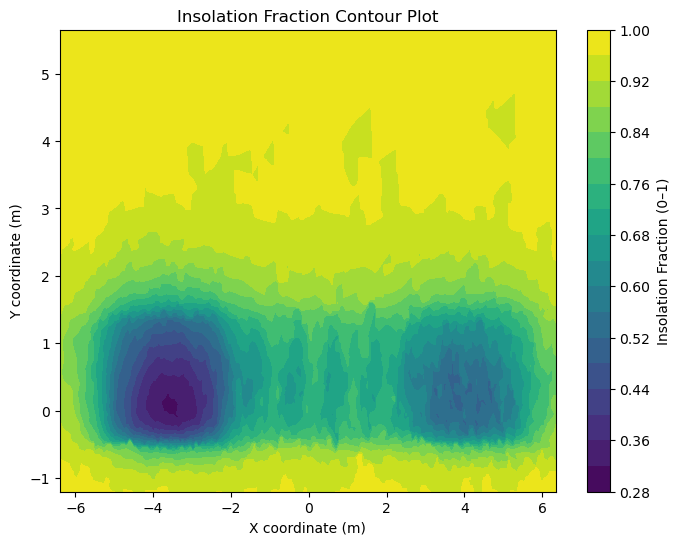

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr_test_Season_5cm_Row1_Module2.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get coordinate grids ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape data ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Normalize for Insolation Fraction ---
Zmax = Z.max()
Znorm = Z / Zmax

# --- Create meshgrid for contour plot ---
X, Y = np.meshgrid(xs, ys, indexing='ij')

# --- Plot contour ---
plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, Znorm, levels=20, cmap='viridis')

plt.colorbar(contour, label='Insolation Fraction (0–1)')
plt.xlabel('X coordinate (m)')
plt.ylabel('Y coordinate (m)')
plt.title('Insolation Fraction Contour Plot')

plt.show()
